# Inspection of polygons extracted from nominatims

This notebook takes an Excel file with a list of cities:

|name_en|country_en|nominatim_query|...|comments|accepted|
|:-----:|:--------:|:-------------:|:-:|:------:|:------:|
|...|...|...|...|...|...|

and uses the `nominatim_query` to extracts and plots the polygons of each cities from OpenStreetMap.

All querys are intialized as `name_en`. By checking each polygon individually, one can see if the nominatim needs to be changed in order to extract the right polygon.

To search for the correct nominatim, one can use [Nominatim Search](https://nominatim.openstreetmap.org/ui/search.html).

## Setup

In [132]:
%run -i "functions.py"
cityfilename = "european_100000pop_comments.xlsx"

## Load cities

In [23]:
df_cities = pd.read_excel(
    '../cities/development/' + cityfilename,
    sheet_name = 'Comments',
    usecols = "A:C,E",
    dtype=str
    )
header_cities = list(df_cities.columns)

cities = {
    slugify(row[0]) + '_' + slugify(row[3]): {
        header_cities[0]: row[0], header_cities[1]: row[1], header_cities[2]: row[2]
    }
    for row in df_cities.itertuples(index=False, name=None)
}

os.makedirs("../plots/", exist_ok=True)
geojson_path = "../cities/boundaries/"
os.makedirs(geojson_path, exist_ok=True)
cities

{'a-coruna_es': {'name_en': 'A Coruña',
  'country_en': 'Spain',
  'nominatim_query': 'A Coruña'},
 'aachen_de': {'name_en': 'Aachen',
  'country_en': 'Germany',
  'nominatim_query': 'Aachen'},
 'aalborg_dk': {'name_en': 'Aalborg',
  'country_en': 'Denmark',
  'nominatim_query': 'Aalborg Municipality'},
 'aarhus_dk': {'name_en': 'Aarhus',
  'country_en': 'Denmark',
  'nominatim_query': 'Aarhus Municipality'},
 'aberdeen_gb': {'name_en': 'Aberdeen',
  'country_en': 'United Kingdom',
  'nominatim_query': 'Aberdeen'},
 'aix-en-provence_fr': {'name_en': 'Aix-En-Provence',
  'country_en': 'France',
  'nominatim_query': 'Aix-En-Provence'},
 'albacete_es': {'name_en': 'Albacete',
  'country_en': 'Spain',
  'nominatim_query': 'Albacete'},
 'alcala-de-henares_es': {'name_en': 'Alcalá De Henares',
  'country_en': 'Spain',
  'nominatim_query': 'Alcalá De Henares'},
 'alchevsk_ua': {'name_en': 'Alchevsk',
  'country_en': 'Ukraine',
  'nominatim_query': 'Alchevsk'},
 'alcobendas_es': {'name_en': 'A

## Check city boundaries

In [3]:
# Takes about ~30 minutes to run with the final nominatims for European cities with >100k population

cities_with_no_polygon = []
cities_with_multipolygon = []
cities_with_no_results = []

for i, (cityid, city_info) in enumerate(tqdm(cities.items(), desc="Checking city boundaries", position=0, leave=True)):

    # Create a folder for each country in the "../plots/" folder
    country = slugify(city_info['country_en'])
    os.makedirs(f"../plots/{country}", exist_ok=True)
    
    
    # Check if plot for city already exists
    city_name = cityid.split("_")[0]
    output_path = f"../plots/{country}/boundary_{city_name}.jpeg"
    if os.path.exists(output_path):
        continue

    

    # Draw location polygons and their holes
    if city_info["nominatim_query"]:
    
        location = geocode_cached(geojson_path, cityid, city_info["nominatim_query"])
        if location == "no_polygon":
            cities_with_no_polygon.append(city_info["name_en"])
            continue
        if location == "no_results":
            cities_with_no_results.append(city_info["name_en"])
            continue
        is_poly, geoms, has_holes, polyg = analyse_polygon(location)
    
    else:
        # https://github.com/mszell/bikenwgrowth/blob/main/code/01_prepare_networks.ipynb
        shp = gpd.read_file("../cities/"+cityid+".shp")
        location = shp.iloc[0].geometry

    # Check if returned geometry is a polygon
    if not is_poly:
        cities_with_no_polygon.append(city_info["name_en"])
        continue
    
    # Check if returned geometry is a multipolygon
    if geoms > 1:
        cities_with_multipolygon.append(city_info["name_en"])
    

    # Plot
    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    if geoms > 1:
        geom_list = list(location.geoms)
        colors = cm.rainbow(np.linspace(0, 1, len(geom_list)))
        for poly, c in zip(geom_list, colors):
            plt.plot(*poly.exterior.xy, c=c, linewidth=2)
            for intr in poly.interiors:
                plt.plot(*intr.xy, c="red", linewidth=1)
    else:
        plt.plot(*location.exterior.xy, linewidth=2)
        for intr in location.interiors:
            plt.plot(*intr.xy, c="red", linewidth=1)

    
    # Largest polygon (holes filled) in black
    plt.plot(*polyg.exterior.xy, c="black", linewidth=2)
    
    # Add a basemap
    for attempt in range(3):
        try:
            contextily.add_basemap(ax=ax, source=contextily.providers.CartoDB.Positron,
                                    crs='EPSG:4326', alpha = 0.8)
            break
        except AttributeError:
            time.sleep(2)
    else:
        print(f"basemap failed for {cityid}, skipping")
    
    plt.gca().set_aspect('equal')
    
    ax.set_title(city_info["name_en"]+", "+city_info["country_en"])
    
    fig.savefig(f"../plots/{country}/boundary_{city_name}.jpeg", dpi=150, bbox_inches='tight')
    
    plt.close()

Checking city boundaries:   0%|          | 0/456 [00:00<?, ?it/s]

Checking city boundaries: 100%|██████████| 456/456 [23:58<00:00,  3.16s/it]


## Individual checks

First we check the cities which queries didn't return any result, and change the nominatim queries to something fitting.

Then we check the cities which queries didn't return a polygon, and change the nominatim queries to something fitting.

Finally, we check each city individually comparing the plot polygon with the equivalent in Google Maps, labelling different polygons in the `comments` column of the Excel, using the following tags:
- **bigger**: if the polygon was bigger, extracting metropolitan areas or whole regions instead of just the municipality
- **other**: if the polygon extracted was from another location

For polygons that match Google Maps, we change the value from 0 to 1 in the `accepted` column.

### Non-capital European cities

#### Cities with no results

In [14]:
# First pass
# Check which cities had no results from the query
cities_with_no_results

['Pésterion', 'Shauliai']

These cities had the wrong name in the UN Demographics Yearbook

- Pésterion = Peristeri (Greece)
- Shauliai = Šiauliai (Lithuania)

We change in the Excel file and load the file again.

In [17]:
# Second pass (after re-running the loop cell in "Check city boundaries")

# Check which cities had no results from the query
cities_with_no_results

[]

#### Cities without a polygon

In [22]:
# First pass
# Check cities where the query returned a geometry but it was not a polygon
cities_with_no_polygon

['Aalborg',
 'Aarhus',
 'Esbjerg',
 'Frederiksberg',
 'Heraklion',
 'Calithèa',
 'Larissa',
 "Luts'K",
 'Odense',
 'Patras',
 'Piraeus',
 'Uzhhorod',
 'Vejle']

These cities had a geometry extracted that wasn't a polygon:

Denmark:
- Aalborg
- Aarhus
- Esbjerg
- Frederiksberg
- Odense
- Vejle

Greece:
- Piraeus
- Heraklion
- Larissa
- Calithèa
- Patras

Ukraine:
- Luts'K
- Uzhhorod

They represent all Danish and Greek cities, and some from Ukraine.

For Danish cities, we add "Municipality" in the query:
|    name_en    |     new nominatim_query    |
|:-------------:|:--------------------------:|
|    Aalborg    |    Aalborg Municipality    |
|     Aarhus    |     Aarhus Municipality    |
|    Esbjerg    |    Esbjerg Municipality    |
| Frederiksberg | Frederiksberg Municipality |
|     Odense    |     Odense Municipality    |
|     Vejle     |     Vejle Municipality     |

For Greek cities, we use the Greek name in the query:
|  name_en  | new nominatim_query |
|:---------:|:-------------------:|
|  Piraeus  |       Πειραιάς      |
| Heraklion |       Ηράκλειο      |
|  Larissa  |        Λάρισα       |
| Calithèa -> Kallithea |       Καλλιθέα      |
|   Patras  |        Πάτρα        |
- The city Kallithea was mispelled as Calithèa from the UN source.

For Ukraine we correct the name and use a tested nominatim in OSM's nominatim web interface
|  name_en  | new nominatim_query |
|:---------:|:-------------------:|
|  Luts'K  |       Lutsk      |
| Uzhhorod |       Uzhhorod Urban Hromada      |

In [25]:
# Second pass (after re-running the loop cell in "Check city boundaries")
# Check cities where the query returned a geometry but it was not a polygon
cities_with_no_polygon

['Heraklion', 'Larissa', 'Patras']

The nominatims for Heraklion, Larissa, and Patras still don't work.

For each of the 3 cities, we find a working nominatim:

New query returns a multipolygon.


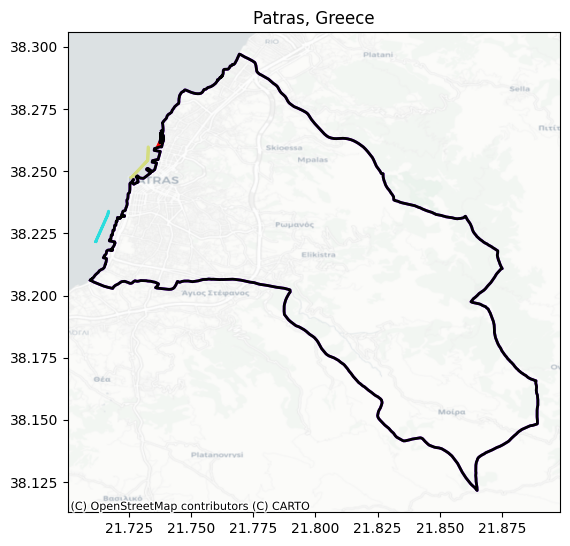

In [41]:
# (This cell is run for all three cities, changing the variable 'city' and 'new_nominatim_query')

# Draw location polygons and their holes
city = 'patras_gr'
city_info = cities[city]
country = slugify(cities[city]['country_en'])
new_nominatim_query = "Municipal Unit of Patras"

# Draw location polygons and their holes
location = geocode_cached(geojson_path, city, new_nominatim_query, check_cache = False)
if location == "no_polygon":
    print("New query doesn't return a polygon.")

elif location == "no_results":
    print("New query doesn't return any result.")

else:
    is_poly, geoms, has_holes, polyg = analyse_polygon(location)

    if not is_poly:
        print("New query doesn't return a polygon.")
        

    if geoms > 1:
        print("New query returns a multipolygon.")


    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    if geoms > 1:
        geom_list = list(location.geoms)
        colors = cm.rainbow(np.linspace(0, 1, len(geom_list)))
        for poly, c in zip(geom_list, colors):
            plt.plot(*poly.exterior.xy, c=c, linewidth=2)
            for intr in poly.interiors:
                plt.plot(*intr.xy, c="red", linewidth=1)
    else:
        plt.plot(*location.exterior.xy, linewidth=2)
        for intr in location.interiors:
            plt.plot(*intr.xy, c="red", linewidth=1)


    # Largest polygon (holes filled) in black
    plt.plot(*polyg.exterior.xy, c="black", linewidth=2)

    for attempt in range(3):
        try:
            contextily.add_basemap(ax=ax, source=contextily.providers.CartoDB.Positron,
                                    crs='EPSG:4326', alpha = 0.8)
            break
        except AttributeError:
            time.sleep(2)
    else:
        print(f"basemap failed for {city}")

    plt.gca().set_aspect('equal')

    ax.set_title(city_info["name_en"]+", "+city_info["country_en"])

    plt.show()

In [ ]:
# Update plot and 
city_name = city.split('_')[0]
fig.savefig(f"../plots/{country}/boundary_{city_name}.jpeg", dpi=150, bbox_inches='tight')
plt.close()
cities[city]['nominatim_query'] = new_nominatim_query

##### Update Excel file

|name_en|old nominatim_query|new nominatim_query|
|:---:|:---:|:---:|
|Heraklion|Heraklion | Heraklion Municipal Unit|
|Larissa|Larissa | Municipal Unit of Larissa|
|Patras|Patras | Municipal Unit of Patras|

#### Cities tagged in Excel after check

In [133]:
# Load comments
df_cities_comments = pd.read_excel(
    '../cities/development/' + cityfilename,
    sheet_name = 'Comments',
    usecols = "A:B,E,G",
    dtype=str
    )
df_cities_comments

,name_en,country_en,alpha-2,comments
0,A Coruña,Spain,ES,"Polygon is OSM bigger than Maps, but there is ..."
1,Aachen,Germany,DE,NaN
2,Aalborg,Denmark,DK,"Polygon is OSM bigger than Maps, but there is ..."
3,Aarhus,Denmark,DK,"Polygon is OSM bigger than Maps, but there is ..."
4,Aberdeen,United Kingdom,GB,"Polygon is OSM bigger than Maps, but there is ..."
...,...,...,...,...
451,Zhytomyr,Ukraine,UA,Insignificant differences
452,Zielona Góra,Poland,PL,NaN
453,Zoetermeer,Netherlands,NL,NaN
454,Zurich,Switzerland,CH,NaN


##### `other`

In [49]:
cities_other = list(df_cities_comments.query("comments == 'other'")['name_en'])
cities_other

['Belfast',
 'Bradford',
 'Brest',
 'Cardiff',
 'Coventry',
 'Ede',
 'Glasgow',
 'Gothenburg',
 'Granada',
 'Leicester',
 'León',
 'Lida',
 'Montreuil',
 'Nîmes',
 'Nis',
 'Porto',
 'Siegen',
 'Westland']

Cities that the initial nominatim extracted a polygon in a completly different location.
- Belfast
- Bradford
- Brest
- Cardiff
- Coventry
- Ede
- Glasgow
- Gothenburg
- Granada
- Leicester
- León
- Lida
- Montreuil
- Nîmes
- Nis
- Porto
- Siegen
- Westland

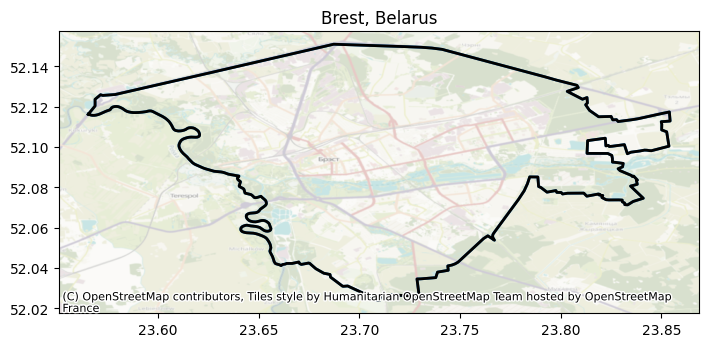

In [ ]:
# (This cell is run for all cities individually, changing the variable 'city' and 'new_nominatim_query')

# Draw location polygons and their holes
city = 'brest_by'
city_info = cities[city]
country = slugify(city_info['country_en'])
new_nominatim_query = "Brest, Belarus"



location = geocode_cached(geojson_path, city, new_nominatim_query, check_cache=False)
if location == "no_polygon":
    print("New query doesn't return a polygon.")
    
elif location == "no_results":
    print("New query doesn't return any result.")
        
else:
    is_poly, geoms, has_holes, polyg = analyse_polygon(location)


    if not is_poly:
        print("New query doesn't return a polygon.")
        

    if geoms > 1:
        print("New query returns a multipolygon.")
        

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    if geoms > 1:
        geom_list = list(location.geoms)
        colors = cm.rainbow(np.linspace(0, 1, len(geom_list)))
        for poly, c in zip(geom_list, colors):
            plt.plot(*poly.exterior.xy, c=c, linewidth=2)
            for intr in poly.interiors:
                plt.plot(*intr.xy, c="red", linewidth=1)
    else:
        plt.plot(*location.exterior.xy, linewidth=2)
        for intr in location.interiors:
            plt.plot(*intr.xy, c="red", linewidth=1)

    # Largest polygon (holes filled) in black
    plt.plot(*polyg.exterior.xy, c="black", linewidth=2)

    contextily.add_basemap(ax=ax, url=contextily.providers.CartoDB.Positron, crs='EPSG:4326', alpha = 0.5)
    plt.gca().set_aspect('equal')
    ax.set_title(city_info["name_en"]+", "+city_info["country_en"])
    plt.show()

In [92]:
city_name = city.split('_')[0]
fig.savefig(f"../plots/{country}/boundary_{city_name}.jpeg", dpi=150, bbox_inches='tight')
plt.close()
cities[city]['nominatim_query'] = new_nominatim_query

Update Excel

|name_en        |new nominatim_query        |
|:-------------:|:-------------------------:|
|Belfast        |Belfast city Distrcit      |
|Bradford       |Bradford, West Yorkshire   |
|Brest          |Brest, Belrus              |
|Cardiff        |Cardiff, Wales             |
|Coventry       |Coventry, United Kingdom   |
|Ede            |Ede 16, Netherlands        |
|Glasgow        |Glasgow City               |
|Gothemburg     |Göteborg                   |
|Granada        |Granada, Spain             |
|Leicester      |Leicester City             |
|León           |León 16, Spain             |
|Lida           |Lida, Belarus              |
|Montreuil      |Montreuil, Ile-de-France   |
|Nîmes          |Nîmes, France              |
|Nis            |Nis, Serbia                |
|Porto          |Oporto                     |
|Siegen         |Siegen, Germany            |
|Westland       |Westland, Netherlands      |

##### `bigger`

In [111]:
cities_bigger = df_cities_comments.query("comments == 'bigger'")
cities_bigger

,name_en,country_en,alpha-2,comments
0,A Coruña,Spain,ES,bigger
2,Aalborg,Denmark,DK,bigger
3,Aarhus,Denmark,DK,bigger
4,Aberdeen,United Kingdom,GB,bigger
6,Albacete,Spain,ES,bigger
...,...,...,...,...
434,Vinnytsia,Ukraine,UA,bigger
435,Vitebsk,Belarus,BY,bigger
436,Vitoria-Gasteiz,Spain,ES,bigger
450,Zaragoza,Spain,ES,bigger


In [112]:
cities_bigger_by_country = cities_bigger.groupby(by='country_en')['name_en'].count()
cities_bigger_by_country

country_en
Albania            1
Belarus            2
Bulgaria           3
Denmark            4
Finland            1
Greece             3
Italy             39
Netherlands        2
Portugal           3
Serbia             1
Spain             48
Sweden             7
Switzerland        1
Ukraine           13
United Kingdom     7
Name: name_en, dtype: int64

The cities where the returned polygon is bigger than the city displayed on Google Maps are (by country):

<details>
<summary><strong>Albania: 1</strong></summary>

- Durrës

</details>

<br>

<details>
<summary><strong>Belarus: 2</strong></summary>

- Soligorsk
- Vitebsk

</details>

<br>

<details>
<summary><strong>Bulgaria: 3</strong></summary>

- Burgas
- Plovdiv
- Stara Zagora
|
</details>

<br>

<details>
<summary><strong>Denmark: 4</strong></summary>

- Aalborg
- Aarhus
- Esbjerg
- Vejle

</details>

<br>

<details>
<summary><strong>Finland: 1</strong></summary>

- Turku

</details>

<br>

<details>
<summary><strong>Greece: 3</strong></summary>

- Heraklion
- Larissa
- Patras

</details>

<br>

<details>
<summary><strong>Italy: 39</strong></summary>

- Bari
- Bergamo
- Bologna
- Bolzano
- Brescia
- Cagliari
- Catania
- Ferrara
- Foggia
- Forli
- Genoa
- Giugliano In Campania
- Latina
- Livorno
- Messina
- Modena
- Monza
- Naples
- Novara
- Padua
- Palermo
- Parma
- Perugia
- Pescara
- Piacenza
- Prato
- Ravenna
- Reggio Di Calabria
- Reggio Nell'Emilia
- Rimini
- Salerno
- Sassari
- Syracuse
- Taranto
- Terni
- Trento
- Trieste
- Verona
- Vicenza

</details>

<br>

<details>
<summary><strong>Netherlands: 2</strong></summary>

- Amersfoort
- Emmen

</details>

<br>

<details>
<summary><strong>Portugal: 3</strong></summary>

- Braga
- Coimbra
- Vila Nova de Gaia

</details>

<br>

<details>
<summary><strong>Serbia: 1</strong></summary>

- Subotica

</details>

<br>

<details>
<summary><strong>Spain: 48</strong></summary>

- A Coruña
- Albacete
- Algeciras
- Alicante/Alacant
- Badajoz
- Barakaldo
- Bilbao
- Burgos
- Cádiz
- Cartagena
- Castelló De La Plana
- Cordova
- Donostia/San Sebastián
- Dos Hermanas
- Elche/Elx
- Fuenlabrada
- Getafe
- Gijón
- Girona
- Granada
- Huelva
- Jaén
- Jerez De La Frontera
- Las Palmas De Gran Canaria
- Leganés
- León
- Lleida
- Logroño
- Málaga
- Mataró
- Móstoles
- Murcia
- Ourense
- Oviedo
- Palma
- Parla
- Reus
- Sabadell
- Salamanca
- San Cristóbal De La Laguna
- Santa Cruz De Tenerife
- Santander
- Seville
- Tarragona
- Telde
- Terrassa
- Vitoria-Gasteiz
- Zaragoza

</details>

<br>

<details>
<summary><strong>Sweden: 7</strong></summary>

- Helsingborg
- Jönköping
- Linköping
- Norrköping
- Orebro
- Uppsala
- Västerås

</details>

<br>

<details>
<summary><strong>Switzerland: 1</strong></summary>

- Lausanne

</details>

<br>

<details>
<summary><strong>Ukraine: 13</strong></summary>

- Cherkasy
- Chernihiv
- Donetsk
- Ivano-Frankivsk
- Khmelnitsky
- Kherson
- Luhansk
- Poltava
- Rivne
- Sumy
- Ternopil
- Vinnytsia
- Zhytomyr

</details>

<br>

<details>
<summary><strong>United Kingdom: 7</strong></summary>

- Aberdeen
- Bolton
- Bradford
- Cardiff
- Edinburgh
- Leeds
- Sheffield

</details>

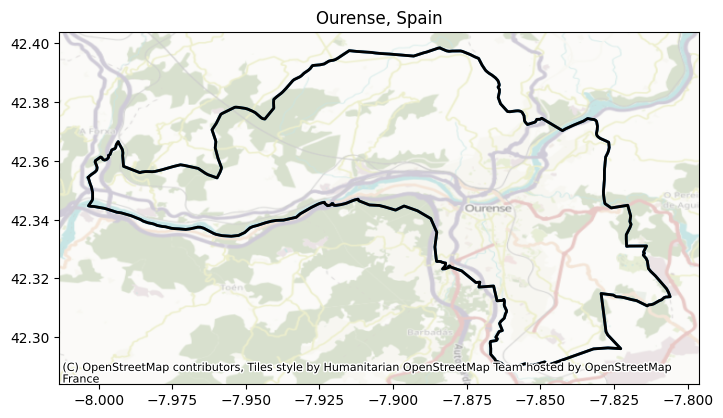

In [ ]:
# (This cell is run for all cities individually, changing the variable 'city' and 'new_nominatim_query')

# Draw location polygons and their holes
city = 'sheffield_uk'
city_info = cities[city]
country = slugify(city_info['country_en'])
new_nominatim_query = "Sheffield"



location = geocode_cached(geojson_path, city, new_nominatim_query, check_cache=False)
if location == "no_polygon":
    print("New query doesn't return a polygon.")
    
elif location == "no_results":
    print("New query doesn't return any result.")
        
else:
    is_poly, geoms, has_holes, polyg = analyse_polygon(location)


    if not is_poly:
        print("New query doesn't return a polygon.")
        

    if geoms > 1:
        print("New query returns a multipolygon.")
        

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    if geoms > 1:
        geom_list = list(location.geoms)
        colors = cm.rainbow(np.linspace(0, 1, len(geom_list)))
        for poly, c in zip(geom_list, colors):
            plt.plot(*poly.exterior.xy, c=c, linewidth=2)
            for intr in poly.interiors:
                plt.plot(*intr.xy, c="red", linewidth=1)
    else:
        plt.plot(*location.exterior.xy, linewidth=2)
        for intr in location.interiors:
            plt.plot(*intr.xy, c="red", linewidth=1)

    # Largest polygon (holes filled) in black
    plt.plot(*polyg.exterior.xy, c="black", linewidth=2)

    contextily.add_basemap(ax=ax, url=contextily.providers.CartoDB.Positron, crs='EPSG:4326', alpha = 0.5)
    plt.gca().set_aspect('equal')
    ax.set_title(city_info["name_en"]+", "+city_info["country_en"])
    plt.show()

In [ ]:
fig.savefig(f"../plots/{country}/boundary_{city}.jpeg", dpi=150, bbox_inches='tight')
plt.close()

Update Excel

|       name_en      |             new nominatim_query            |
|:------------------:|:------------------------------------------:|
| Durrës             | Durrës, Bashkia   Durrës, Northern Albania |
| Vitebsk            | Vitebsk, Vitebsk                           |
| Burgas             | Burgas, Burgas                             |
| Plovdiv            | Plovdiv, Plovdiv                           |
| Stara Zagora       | Stara Zagora, Stara Zagora                 |
| Bolzano            | Bolzano, Bolzano                           |
| Brescia            | Brescia, Brescia                           |
| Ferrara            | Ferrara, Ferrara                           |
| Foggia             | Foggia, Foggia                             |
| Forli              | Forli, Forli                               |
| Latina             | Latina, Latina                             |
| Livorno            | Livorno, Livorno                           |
| Modena             | Modena, Modena                             |
| Monza              | Monza, Monza                               |
| Novara             | Novara, Novara                             |
| Padua              | Padua, Padua                               |
| Parma              | Parma, Parma                               |
| Perugia            | Perugia, Perugia                           |
| Pescara            | Pescara, Pescara                           |
| Piacenza           | Piacenza, Piacenza                         |
| Prato              | Prato, Prato                               |
| Ravenna            | Ravenna, Ravenna                           |
| Reggio Nell'Emilia | Reggio Nell'Emilia, Reggio Nell'Emilia     |
| Rimini             | Rimini, Rimini                             |
| Salerno            | Salerno, Salerno                           |
| Taranto            | Taranto, Taranto                           |
| Terni              | Terni, Terni                               |
| Trento             | Trento, Trento                             |
| Verona             | Verona, Verona                             |
| Vicenza            | Vicenza, Vicenza                           |
| Amersfoort         | Amersfoort 16                              |
| Emmen              | Emmen 16                                   |
| Granada            | Granada, Spain                             |
| León               | León 16, Spain                             |
| Ourense            | Ourense, Ourense                           |
| Orebro             | Orebro kommun                              |
| Cherkasy           | Cherkasy, Cherkasy                         |
| Chernihiv          | Chernihiv, Chernihiv                       |
| Donetsk            | Donetsk, Donetsk                           |
| Ivano-Frankivsk    | Ivano-Frankivsk, Ivano-Frankivsk           |
| Kherson            | Kherson, Kherson                           |
| Khmelnitsky        | Khmelnytskyi, Khmelnytskyi                 |
| Luhansk            | Luhansk, Luhansk                           |
| Luts'K             | Lutsk                                      |
| Poltava            | Poltava, Poltava                           |
| Rivne              | Rivne, Rivne                               |
| Sumy               | Sumy, Sumy                                 |
| Ternopil           | Ternopil, Ternopil                         |
| Vinnytsia          | Vinnytsia, Vinnytsia                       |
| Zhytomyr           | Zhytomyr, Zhytomyr                         |

In [ ]:
cityfilepath = '../cities/european_100000pop_dev.csv'

with open(cityfilepath, mode='w', newline = '', encoding='utf-8') as outfile:
    writer = csv.DictWriter(
        outfile,
        fieldnames = header_cities,
        delimiter = ";"
    )

    writer.writeheader()
    writer.writerows(cities.values())

## Extract accepted cities and nominatims to a .csv file

In [ ]:
european_100000pop = pd.read_excel(
    '../cities/development/' + cityfilename,
    sheet_name = 'Comments',
    usecols = "A:C,E:F,H"
    ).query("accepted == 1").drop(columns = ['accepted']).sort_values(by=['name_en', 'country_en']).reset_index(drop=True)
european_100000pop

,name_en,country_en,nominatim_query,alpha-2,population
0,Aachen,Germany,Aachen,DE,247380
1,Aix-En-Provence,France,Aix-En-Provence,FR,142668
2,Alcalá De Henares,Spain,Alcalá De Henares,ES,195570
3,Alchevsk,Ukraine,Alchevsk,UA,105580
4,Alcobendas,Spain,Alcobendas,ES,116895
...,...,...,...,...,...
355,Zielona Góra,Poland,Zielona Góra,PL,141631
356,Zoetermeer,Netherlands,Zoetermeer,NL,124025
357,Zurich,Switzerland,Zurich,CH,423193
358,Zwolle,Netherlands,Zwolle,NL,123861


In [ ]:
# Save clean european_100000pop.csv
european_100000pop.to_csv(
    "../cities/development/european_100000pop.csv",
    sep = ";",
    index = False,
)